### Create a Bounding Box to Define around the Sites for Downloading HRRR-AK Data 

Notebook contents 
* defines the HRRR-AK bounding box based on lat/lon of sites, and configures a buffer based on n-gridcells away from sites
* plots the bounding box and sites

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **herbie** for mapping

Just for fun, I installed a basemap package in `herbie` which python environment,\
let's see if it works for plotting at the end 

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

Extra plotting packages, 

In [2]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.patches import Rectangle

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

# Function that defines the bounding box 

In [4]:
def build_bbox(sites_df, grid_km=3, n_cells=1):
    """
    Build a bounding box around sites with a buffer.

    Parameters
    ----------
    sites_df : pandas.DataFrame
        Must contain columns: ['lat', 'lon']
    grid_km : float
        Grid spacing in kilometers (HRRR-AK = 3 km)
    n_cells : int
        Number of grid cells to buffer around domain

    Returns
    -------
    dict with:
        lat_min, lat_max, lon_min, lon_max
        grib_area_string
    """

    # --- raw bounds ---
    lat_min = sites_df["lat"].min()
    lat_max = sites_df["lat"].max()
    lon_min = sites_df["lon"].min()
    lon_max = sites_df["lon"].max()

    # --- convert grid spacing to degrees ---
    # 1 degree latitude ≈ 111 km
    buffer_km = grid_km * n_cells
    lat_buffer = buffer_km / 111.0

    # longitude depends on latitude
    mean_lat = sites_df["lat"].mean()
    lon_buffer = buffer_km / (111.0 * np.cos(np.radians(mean_lat)))

    # --- apply buffer ---
    lat_min_b = lat_min - lat_buffer
    lat_max_b = lat_max + lat_buffer
    lon_min_b = lon_min - lon_buffer
    lon_max_b = lon_max + lon_buffer

    # --- GRIB string ---
    grib_area = f"{lon_min_b:.4f}:{lon_max_b:.4f} {lat_min_b:.4f}:{lat_max_b:.4f}"

    return {
        "lat_min": lat_min_b,
        "lat_max": lat_max_b,
        "lon_min": lon_min_b,
        "lon_max": lon_max_b,
        "grib_area_string": grib_area
    }

## Parameter Guide 

| n_cells | Buffer distance | Use case                          |
| ------- | --------------- | --------------------------------- |
| 1       | ~3 km           | Minimal point extraction          |
| 2       | ~6 km           | Safe HRRR point forcing           |
| 3–4     | 9–12 km         | Wind downscaling, terrain effects |


### Create Bounding Box for the Main Point Modeling Sites 

In [12]:
sites_main = pd.DataFrame({
    "name": ["ppsa2", "tram", "snotel", "tkg4"],
    "lat": [58.262, 58.2971, 58.7, 58.63447],
    "lon": [-134.517, -134.386, -134.8667, -134.23708]
})

bbox_main = build_bbox(sites_main, grid_km=3, n_cells=4)

print("Main sites bounding box:")
print(bbox_main["grib_area_string"])

Main sites bounding box:
-135.0734:-134.0303 58.1539:58.8081


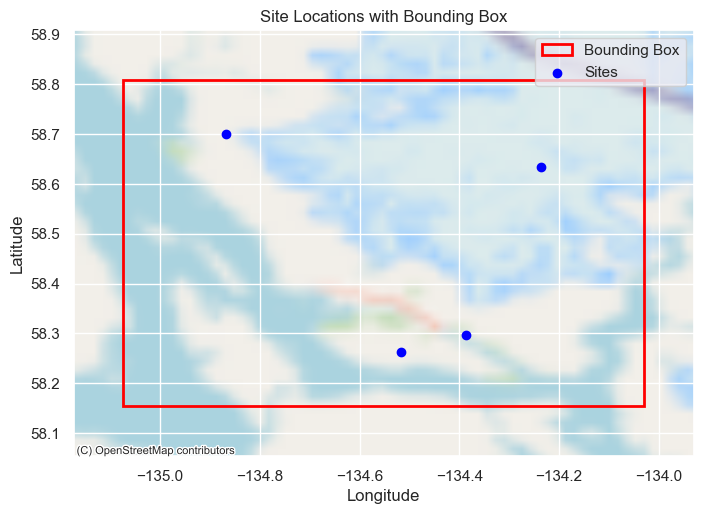

In [11]:
# Assuming sites_main and bbox_main are defined
# sites_main should have 'lon' and 'lat' columns/keys
# bbox_main should be a dict like {'lon_min': ..., 'lon_max': ..., 'lat_min': ..., 'lat_max': ...}

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 8))

# Set axis limits to your bounding box (with a small buffer for padding)
buffer = 0.1  # Adjust as needed (degrees)
ax.set_xlim(bbox_main["lon_min"] - buffer, bbox_main["lon_max"] + buffer)
ax.set_ylim(bbox_main["lat_min"] - buffer, bbox_main["lat_max"] + buffer)
ax.set_aspect('equal')  # Prevents distortion

# Add the basemap (using OpenStreetMap as a reliable alternative to Stamen)
try:
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=6)  # Adjust zoom if needed
except Exception as e:
    print(f"Basemap failed to load: {e}. Proceeding without it.")

# Add the bounding box rectangle
rect = Rectangle(
    (bbox_main["lon_min"], bbox_main["lat_min"]),
    bbox_main["lon_max"] - bbox_main["lon_min"],
    bbox_main["lat_max"] - bbox_main["lat_min"],
    linewidth=2, edgecolor='red', facecolor='none', label='Bounding Box'
)
ax.add_patch(rect)

# Plot the sites
plt.scatter(sites_main["lon"], sites_main["lat"], color='blue', label='Sites')

# Labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Site Locations with Bounding Box')
plt.legend()

# Show the plot
plt.show()

### Create Bounding Box which includes all the JIF Sites

In [7]:
sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,   # main
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067  # icefield
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

bbox_all = build_bbox(sites_all, grid_km=3, n_cells=4)

print("All sites bounding box:")
print(bbox_all["grib_area_string"])

All sites bounding box:
-135.0752:-133.5013 58.1539:59.6837


That's with a 4 gridcell buffer, so let's go with that for now. 

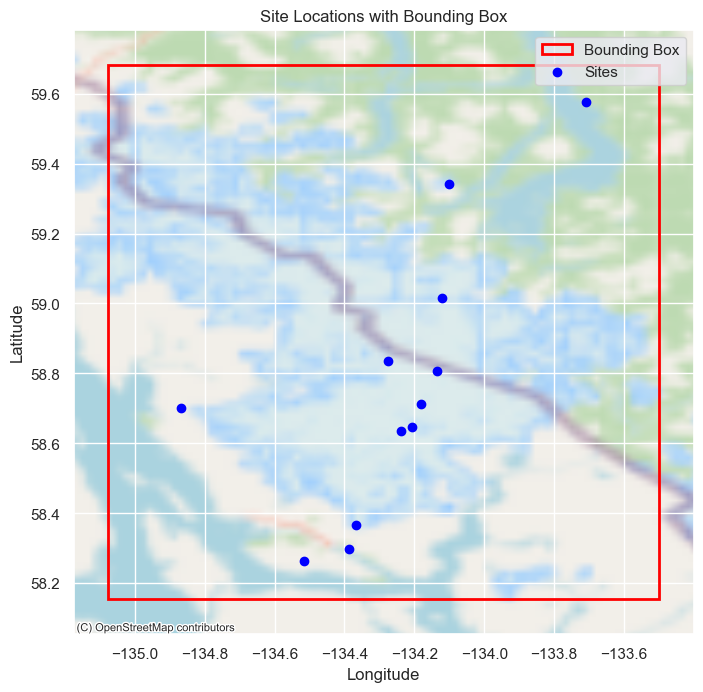

In [8]:
# Assuming sites_all and bbox_all are defined
# sites_all should have 'lon' and 'lat' columns/keys
# bbox_all should be a dict like {'lon_min': ..., 'lon_max': ..., 'lat_min': ..., 'lat_max': ...}

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 8))

# Set axis limits to your bounding box (with a small buffer for padding)
buffer = 0.1  # Adjust as needed (degrees)
ax.set_xlim(bbox_all["lon_min"] - buffer, bbox_all["lon_max"] + buffer)
ax.set_ylim(bbox_all["lat_min"] - buffer, bbox_all["lat_max"] + buffer)
ax.set_aspect('equal')  # Prevents distortion

# Add the basemap (using OpenStreetMap as a reliable alternative to Stamen)
try:
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=6)  # Adjust zoom if needed
except Exception as e:
    print(f"Basemap failed to load: {e}. Proceeding without it.")

# Add the bounding box rectangle
rect = Rectangle(
    (bbox_all["lon_min"], bbox_all["lat_min"]),
    bbox_all["lon_max"] - bbox_all["lon_min"],
    bbox_all["lat_max"] - bbox_all["lat_min"],
    linewidth=2, edgecolor='red', facecolor='none', label='Bounding Box'
)
ax.add_patch(rect)

# Plot the sites
plt.scatter(sites_all["lon"], sites_all["lat"], color='blue', label='Sites')

# Labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Site Locations with Bounding Box')
plt.legend()

# Show the plot
plt.show()

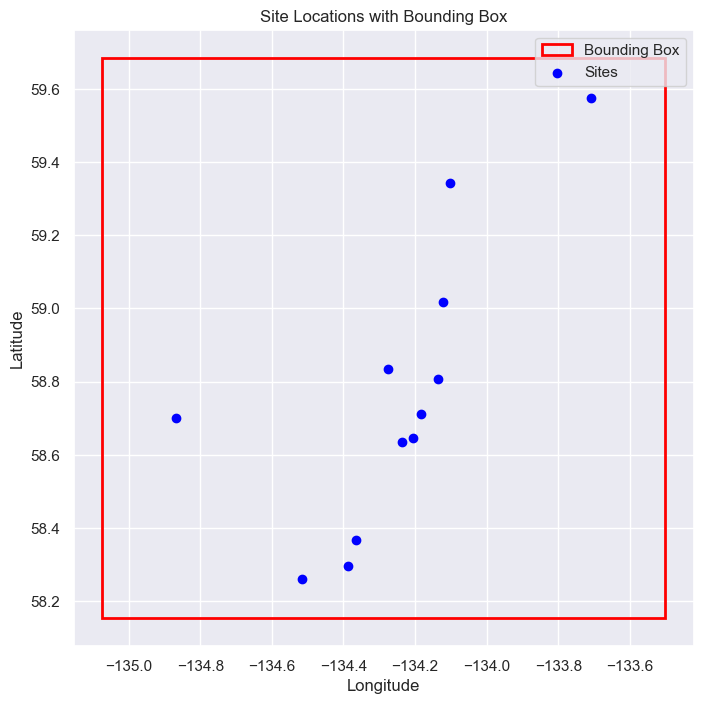

In [9]:
# now plot the sites and bounding box to check it looks right
fig, ax = plt.subplots(figsize=(8,8))

# add a background map of alaska (optional, requires contextily)
# ax = plt.gca()
# ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Stamen.TerrainBackground)

# add a rectangle for the bounding box
from matplotlib.patches import Rectangle
bbox = bbox_all
rect = Rectangle((bbox["lon_min"], bbox["lat_min"]), 
                 bbox["lon_max"] - bbox["lon_min"], 
                 bbox["lat_max"] - bbox["lat_min"], 
                 linewidth=2, edgecolor='red', facecolor='none', label='Bounding Box')
ax.add_patch(rect)

plt.scatter(sites_all["lon"], sites_all["lat"], color='blue', label='Sites')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Site Locations with Bounding Box')
plt.legend()